# Training vs Testing Error: Which Trends are we Fitting?

## Learning Objectives
By the end of this notebook, we will understand:
- **The fundamental problem of overfitting**: Why models that fit training data perfectly may fail on new data
- **Signal vs Noise**: How to distinguish between true patterns -- i.e., patterns or trends that exist in the training data, and also in the testing data -- and patterns that are not shared across the data split, such as random fluctuations.
- **The bias-variance tradeoff in action**: See how model complexity affects generalization
- **Why simpler models often generalize better**: The power of Occam's Razor in machine learning

## The Core Problem
We'll create synthetic data with a clear underlying pattern plus some noise, then demonstrate how:
- **Complex models** (deep trees) can fit the noise in addition to the main pattern, and thus overfit
- **Simple models** (shallow trees) capture the signal because that's all they can do; as a consequence, they generalize better
- **Training accuracy can be misleading** when evaluating model performance

## Key Insight
**The goal of machine learning is not to fit the training data perfectly, but to capture the underlying patterns that generalize to new data.**

## Setting Up Our Environment

We'll use our usual minimal set of libraries:
- **numpy**: For numerical operations and random number generation
- **matplotlib**: For visualization
- **sklearn**: For decision trees and train-test splitting

**Reproducibility**: Setting a random seed ensures we get the same results every time, making our experiments reproducible and debuggable.

In [ ]:
# import important python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
%matplotlib inline

# sets the seed for NumPy's random number generator to a specific value, in this case, 42
# running code always gets same random numbers -- useful for debugging and verifying results.
np.random.seed(42)

## Creating Synthetic Data with Known Patterns

We'll generate data with a **clear underlying signal** plus **controlled noise**:

**The True Pattern (Signal):**
- Points with X₁ > 5 are mostly class 1 (95%)
- Points with X₁ < 5 are mostly class 0 (95%)

**The Noise:**
- 5% of points violate this pattern (random "flips")
- This simulates real-world data where patterns aren't perfect

**Why synthetic data?**
- We know the true underlying pattern
- We can control the amount of noise
- We can clearly see when models fit signal vs. noise



In [ ]:
# data generation mechanism

 # return N labeled points
def gen_labeled_points(N,p):
  # First we generate uniformly distributed points
  rng = default_rng(12) # another way to set the random seed
  X = rng.uniform(low=0.0, high=10.0, size=[N,2])
  y = np.ones(N) # by default set all labels to 1
  # Now we label them
  for i in range(N):
    # generate a p, 1-p coin
    c = 1
    if (rng.uniform(0,1) > 1-p): c = -1.
    if (X[i,0] > 5): y[i] = y[i]*c
    if (X[i,0] < 5): y[i] = -1*y[i]*c
  y = 0.5*(y+1) # make y 0's and 1's
  y = y.astype(int) # return integers, not floats
  return X,y

### Visualizing Our Synthetic Data

Let's see what our generated data looks like:

**What to observe:**
- **Clear separation**: Most blue points (class 1) are on the right (X₁ > 5)
- **Most red points** (class 0) are on the left (X₁ < 5)
- **Noise points**: Some points violate the pattern (5% of each class)
- **The challenge**: A model needs to learn the general pattern while ignoring the noise

We created the data above, hence we already know that the optimal decision boundary should be a vertical line at X₁ = 5, but some points will always be misclassified due to noise.

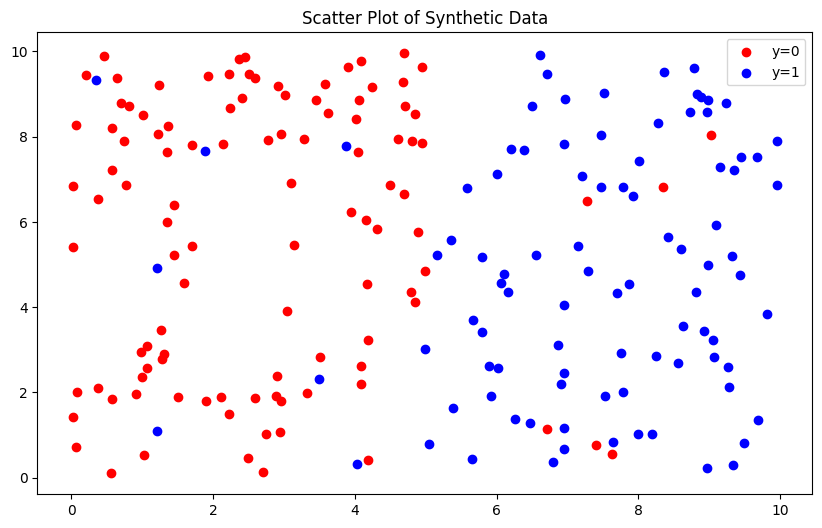

In [ ]:
# N points, probability of color flip = p
N = 200
p = 0.05
X,y = gen_labeled_points(N,p)

# Create a scatter plot
plt.figure(figsize=(10, 6))
for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='blue', label='y=1' if 'y=1' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], color='red', label='y=0' if 'y=0' not in plt.gca().get_legend_handles_labels()[1] else "")

# Adding labels and title
plt.title('Scatter Plot of Synthetic Data')
plt.legend()
plt.show()

## Live Coding

We will try to find what is the "best" decision tree -- best w.r.t. TESTING accuracy.

In [ ]:
# step 1 : partition the data into training and testing 75%-25%

X_LCtrain, X_LCtest, y_LCtrain, y_LCtest = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42)


In [ ]:
# train trees of depth 1 to 10
# train them on X_LCtrain, Y_LCtrain
# compute testing accuracy
training_accuracy = []
testing_accuracy = []
for i in range(1,11):
  dt = tree.DecisionTreeClassifier(max_depth=i)
  dt = dt.fit(X_LCtrain, y_LCtrain)
  training_accuracy.append(dt.score(X_LCtrain,y_LCtrain))
  testing_accuracy.append(dt.score(X_LCtest,y_LCtest))
  print('The training accuracy for the tree of depth', i, 'is:', dt.score
        (X_LCtrain,y_LCtrain))
  print('The testing accuracy for the tree of depth', i, 'is:', dt.score
        (X_LCtest,y_LCtest))
  print()


The training accuracy for the tree of depth 1 is: 0.92
The testing accuracy for the tree of depth 1 is: 0.96

The training accuracy for the tree of depth 2 is: 0.92
The testing accuracy for the tree of depth 2 is: 0.96

The training accuracy for the tree of depth 3 is: 0.9466666666666667
The testing accuracy for the tree of depth 3 is: 0.88

The training accuracy for the tree of depth 4 is: 0.96
The testing accuracy for the tree of depth 4 is: 0.9

The training accuracy for the tree of depth 5 is: 0.98
The testing accuracy for the tree of depth 5 is: 0.84

The training accuracy for the tree of depth 6 is: 0.9866666666666667
The testing accuracy for the tree of depth 6 is: 0.84

The training accuracy for the tree of depth 7 is: 1.0
The testing accuracy for the tree of depth 7 is: 0.88

The training accuracy for the tree of depth 8 is: 1.0
The testing accuracy for the tree of depth 8 is: 0.88

The training accuracy for the tree of depth 9 is: 1.0
The testing accuracy for the tree of dept

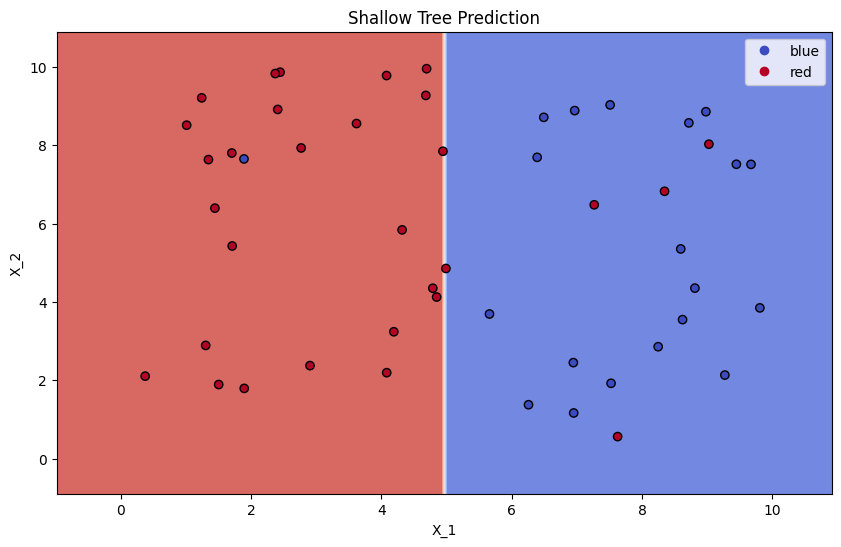

In [ ]:
dt1 = tree.DecisionTreeClassifier(max_depth=1)
dt1 = dt1.fit(X_LCtrain, y_LCtrain)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=-y_train, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Shallow Tree Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


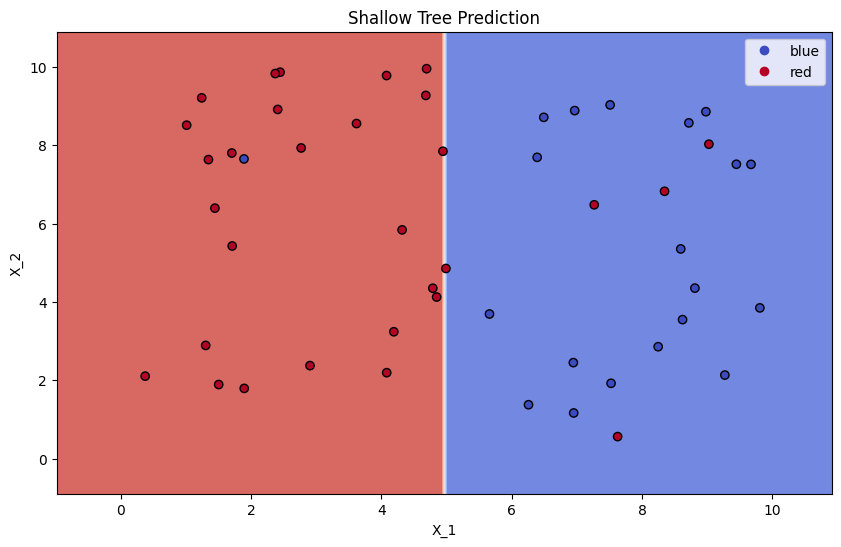

In [ ]:
dt2 = tree.DecisionTreeClassifier(max_depth=2)
dt2 = dt2.fit(X_LCtrain, y_LCtrain)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=-y_train, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Shallow Tree Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


## Train-Test Split: Unusual but Revealing

We'll use an unusual split (25% train, 75% test -- usually we'd see something closer to the reverse proportions) for a specific reason:

**Why this split?**
- **Small training set**: Makes overfitting more obvious
- **Large test set**: Provides reliable performance estimates
- **Demonstrates the problem**: With limited training data, complex models are more likely to overfit


In [ ]:
from sklearn.model_selection import train_test_split #function that splits the dataset into training and testing subsets
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.75, shuffle=True, random_state=42)

### Understanding Our Data Split

Let's visualize both the training and test sets to understand what each model will see:

**Training set characteristics:**
- Only 50 points to learn from
- May not perfectly represent the underlying distribution
- Small sample size makes overfitting more likely

**Test set characteristics:**
- 150 points for evaluation
- Provides a more reliable estimate of true performance
- Shows how well models generalize to unseen data


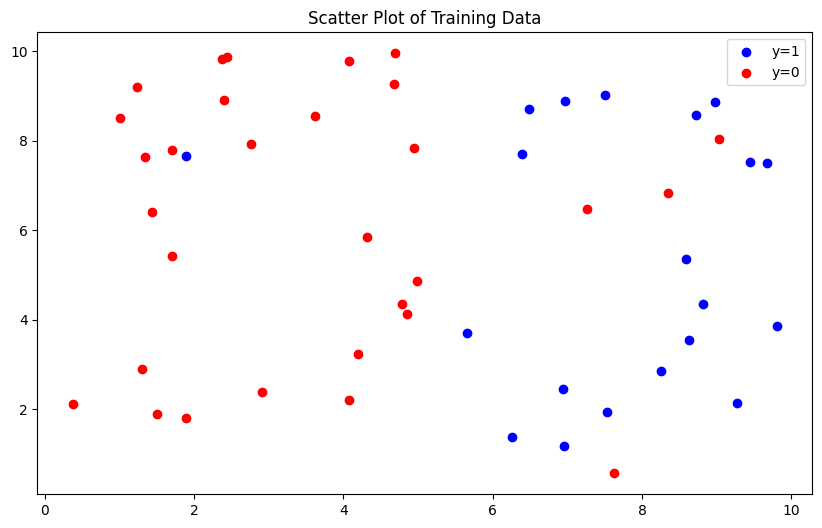

In [ ]:
# training data

# Create a scatter plot
plt.figure(figsize=(10, 6))
for i in range(len(X_train)):
    if y_train[i] == 1:
        plt.scatter(X_train[i, 0], X_train[i, 1], color='blue', label='y=1' if 'y=1' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(X_train[i, 0], X_train[i, 1], color='red', label='y=0' if 'y=0' not in plt.gca().get_legend_handles_labels()[1] else "")

# Adding labels and title
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

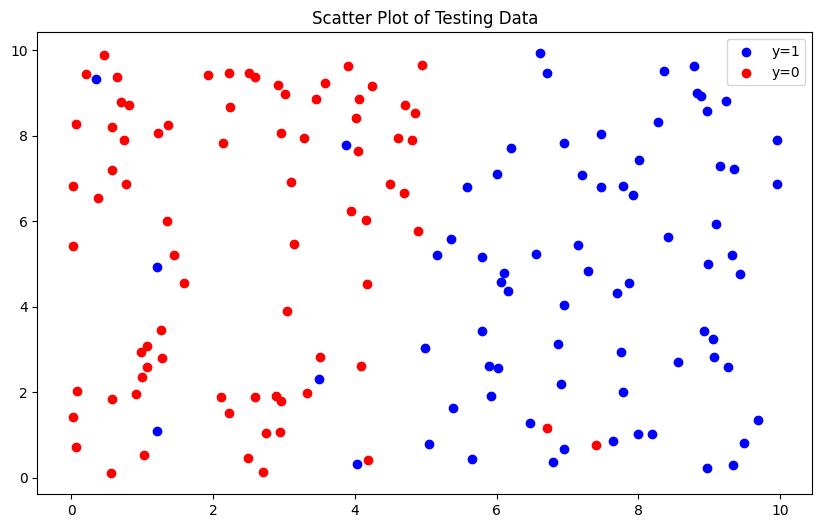

In [ ]:
# testing data

# Create a scatter plot
plt.figure(figsize=(10, 6))
for i in range(len(X_test)):
    if y_test[i] == 1:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='blue', label='y=1' if 'y=1' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(X_test[i, 0], X_test[i, 1], color='red', label='y=0' if 'y=0' not in plt.gca().get_legend_handles_labels()[1] else "")

# Adding labels and title
plt.title('Scatter Plot of Testing Data')
plt.legend()
plt.show()

## Training Two Models: Shallow Tree vs Deep Tree

We'll train two decision trees with very different complexities:

**Shallow Tree (max_depth=1):**
- Can only make one split (one decision)
- Very simple model, with very limited ability to partition the space
- It wants to capture all the variation in the training data, but it cannot. However, it should be able to capture the main pattern: $X₁ > 5$ vs $X₁ < 5$

**Deep Tree (max_depth=6):**
- Can make many splits (up to 2⁶ = 64 leaf nodes)
- Complex model ability to partition the space in intricate ways
- Can fit the training data very well -- it can fit the main trend (or signal) and, as we see, the random flips (the noise)

**The prediction??**

In [ ]:
dt_deep = tree.DecisionTreeClassifier(max_depth=6)
dt_deep = dt_deep.fit(X_train, y_train)
train_score_deep = dt_deep.score(X_train,y_train)
print('The training accuracy for the deep tree is:', train_score_deep)
dt_shallow = tree.DecisionTreeClassifier(max_depth=1)
dt_shallow = dt_shallow.fit(X_train, y_train)
train_score_shallow = dt_shallow.score(X_train,y_train)
print('The training accuracy for the shallow tree is:', train_score_shallow)

The training accuracy for the deep tree is: 1.0
The training accuracy for the shallow tree is: 0.9


### Visualizing Decision Boundaries

The colored regions show how each model divides the feature space:

**What to look for:**
- **Shallow tree**: Should show a simple vertical split around X₁ = 5
- **Deep tree**: May show complex, jagged boundaries
- **Training points**: Colored dots showing true labels
- **Overfitting signs**: Complex boundaries that follow individual training points

The decision boundary helps us judge whether the model learned the true pattern or just memorized the training data.

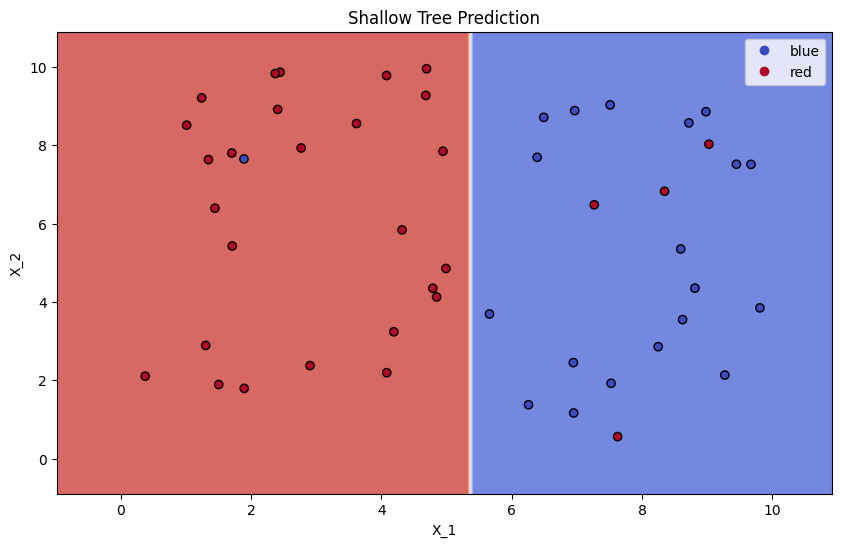

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt_shallow.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=-y_train, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Shallow Tree Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


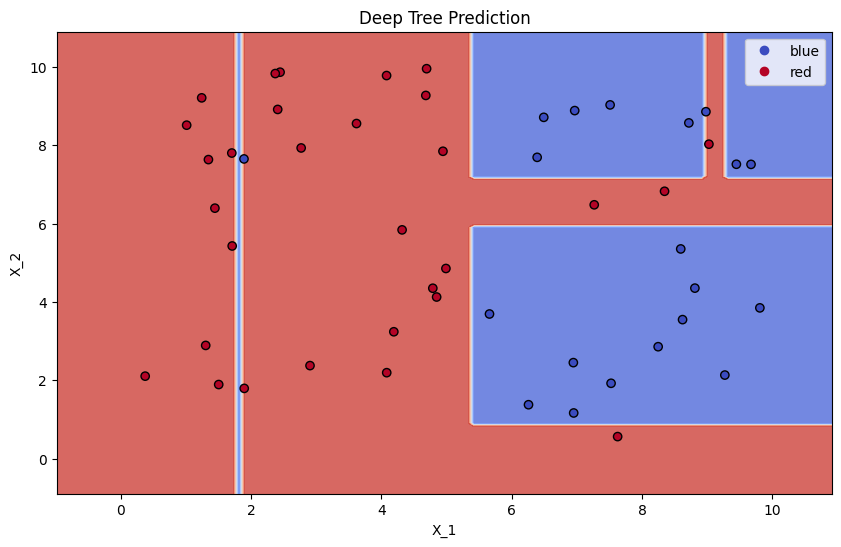

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt_deep.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=-y_train, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Deep Tree Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


## Time to Check: Test Performance

Now we see the real test - how do our models perform on unseen data?

**Expected results:**
- **Deep tree**: High training accuracy (1.0) but lower test accuracy
- **Shallow tree**: Lower training accuracy (0.9) but higher test accuracy

**Why this happens:**
- **Deep tree**: Fitted the noise in training data, doesn't generalize
- **Shallow tree**: Captured the true pattern, generalizes well

The model that performed perfectly on training data actually performs worse on new data!

In [ ]:
train_score_deep = dt_deep.score(X_test,y_test)
print('The testing accuracy for the deep tree is:', train_score_deep)
train_score_shallow = dt_shallow.score(X_test,y_test)
print('The testing accuracy for the shallow tree is:', train_score_shallow)

The testing accuracy for the deep tree is: 0.82
The testing accuracy for the shallow tree is: 0.9266666666666666


### Visualizing Performance on Test Data

Now let's see how our models perform on the test set:

**What to observe:**
- **Test points**: How well do the decision boundaries separate them?
- **Misclassifications**: Where do the models make errors?
- **Pattern recognition**: Does the model capture the true underlying pattern?

**Key questions:**
- Which model's decision boundary better matches the true pattern (vertical line at X₁ = 5)?
- Which model is more robust to the noise in the data?


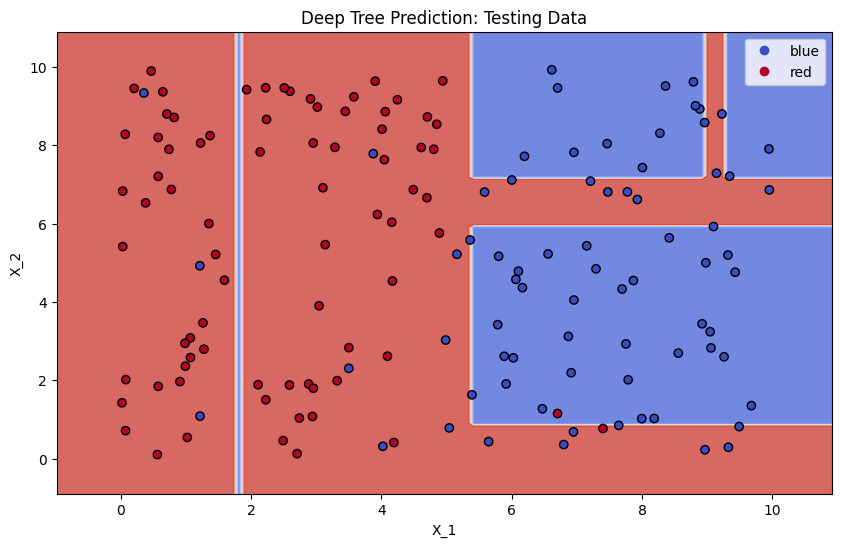

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt_deep.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=-y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Deep Tree Prediction: Testing Data')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


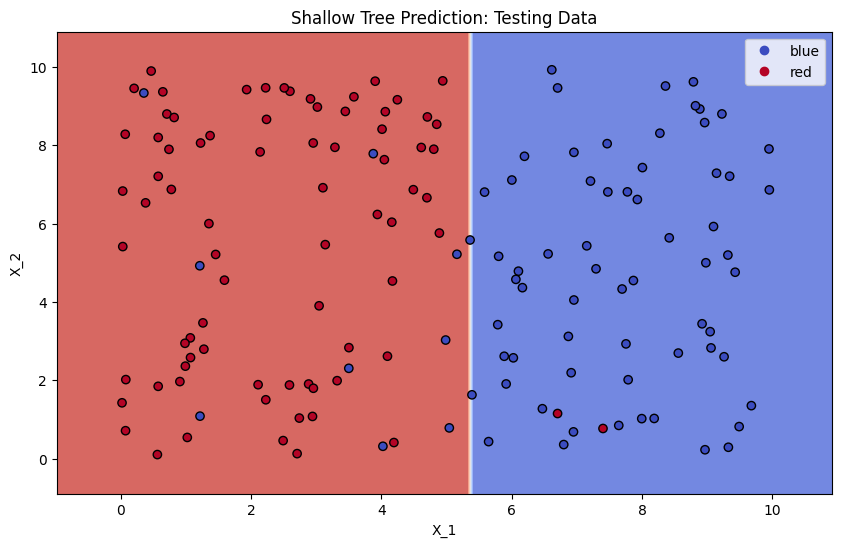

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt_shallow.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=-y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Shallow Tree Prediction: Testing Data')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


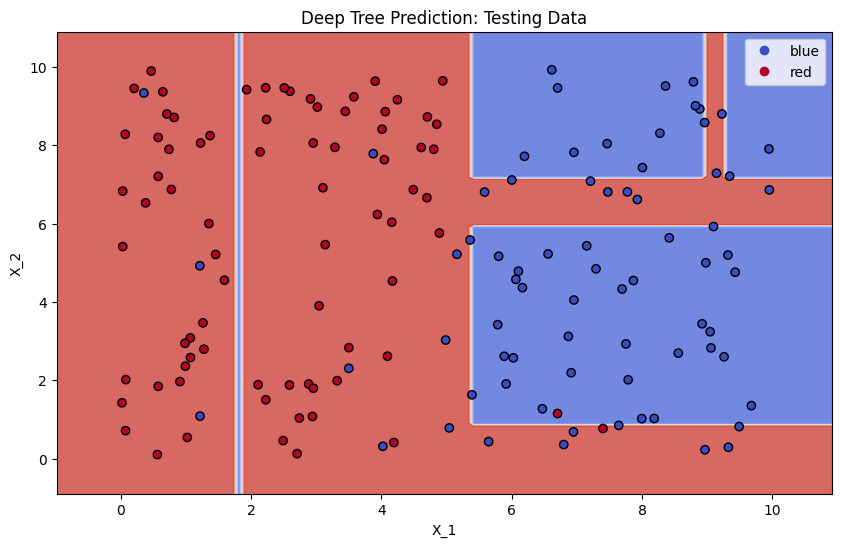

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = dt_deep.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_test[:, 0], X_test[:, 1], c=-y_test, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Deep Tree Prediction: Testing Data')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()


### A First Look at Neural Nets

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Simple neural network with one hidden layer of width k
class SimpleNN(nn.Module):
    def __init__(self, k=10):
        """
        k: width of the hidden layer (controls model complexity)
        """
        super(SimpleNN, self).__init__()
        # Input layer: 2 features
        # Hidden layer: k neurons
        # Output layer: 1 neuron (for binary classification)
        self.fc1 = nn.Linear(2, k)
        self.fc2 = nn.Linear(k, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Hidden layer with ReLU activation
        x = self.sigmoid(self.fc2(x))  # Output layer with sigmoid for binary classification
        return x

In [ ]:
def train_neural_network(model, X_train, y_train, X_test, y_test, epochs=100, lr=0.01):
    """
    Simple training function for binary classification.

    Args:
        model: PyTorch neural network model
        X_train: training features (numpy array)
        y_train: training labels (numpy array)
        X_test: test features (numpy array)
        y_test: test labels (numpy array)
        epochs: number of training epochs
        lr: learning rate

    Returns:
        train_accuracies: list of training accuracies per epoch
        test_accuracies: list of test accuracies (computed every 50 epochs and at the end)
    """
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

    # Loss and optimizer
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_accuracies = []
    test_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

        # Training accuracy (using outputs we already computed - no extra forward pass)
        with torch.no_grad():
            train_pred = (outputs > 0.5).float()
            train_acc = (train_pred == y_train_tensor).float().mean().item()
            train_accuracies.append(train_acc)

        # Test accuracy (only compute every 50 epochs to save time)
        if epoch % 100 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                test_outputs = model(X_test_tensor)
                test_pred = (test_outputs > 0.5).float()
                test_acc = (test_pred == y_test_tensor).float().mean().item()
                test_accuracies.append(test_acc)

    return train_accuracies, test_accuracies

Training accuracy: 1.0000
Test accuracy: 0.8333


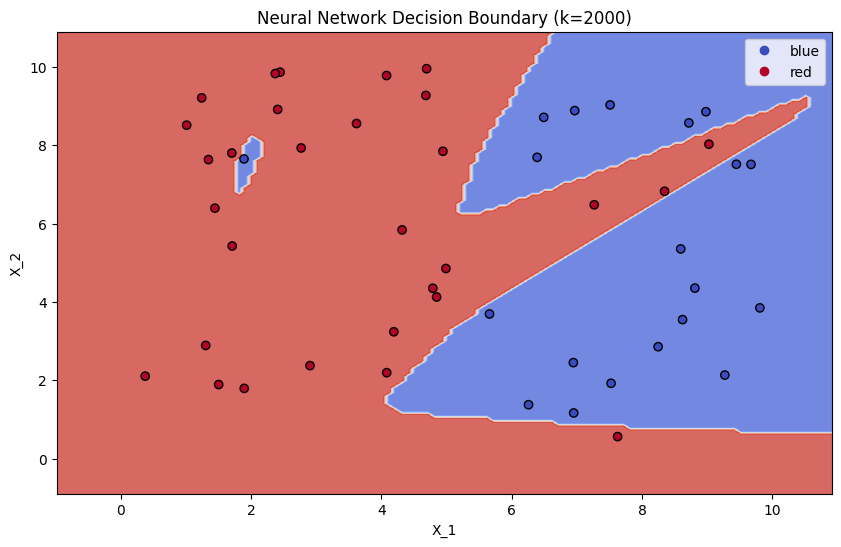

In [ ]:
# Train a neural network with k=50
k = 2000
model = SimpleNN(k=k)

# Train the model
train_accs, test_accs = train_neural_network(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01)

# Report final accuracies
print(f'Training accuracy: {train_accs[-1]:.4f}')
print(f'Test accuracy: {test_accs[-1]:.4f}')

# Create decision boundary plot
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict on the meshgrid
model.eval()
with torch.no_grad():
    mesh_points = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    Z = model(mesh_points).numpy()
    Z = (Z > 0.5).astype(int).reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, -Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=-y_train, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title(f'Neural Network Decision Boundary (k={k})')
plt.legend(handles=scatter.legend_elements()[0], labels=['blue', 'red'])
plt.show()